In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install -q gdown


In [4]:
!wget -O Offroad_Segmentation_Training_Dataset.zip \
"https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_Training_Dataset.zip"

--2026-03-13 00:30:52--  https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_Training_Dataset.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.163.207, 142.250.99.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2794457228 (2.6G) [application/zip]
Saving to: ‘Offroad_Segmentation_Training_Dataset.zip’

Offroad_Segmentatio 100%[===================>]   2.60G   152MB/s    in 17s     

2026-03-13 00:31:10 (154 MB/s) - ‘Offroad_Segmentation_Training_Dataset.zip’ saved [2794457228/2794457228]



In [5]:
!wget -O Offroad_Segmentation_testImages.zip \
"https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_testImages.zip"

--2026-03-13 00:31:13--  https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_testImages.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 173.194.203.207, 74.125.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1158592290 (1.1G) [application/zip]
Saving to: ‘Offroad_Segmentation_testImages.zip’

Offroad_Segmentatio 100%[===================>]   1.08G   270MB/s    in 4.1s    

2026-03-13 00:31:18 (267 MB/s) - ‘Offroad_Segmentation_testImages.zip’ saved [1158592290/1158592290]



In [6]:
!unzip -q Offroad_Segmentation_Training_Dataset.zip
!unzip -q Offroad_Segmentation_testImages.zip

In [7]:
!ls


Offroad_Segmentation_testImages
Offroad_Segmentation_testImages.zip
Offroad_Segmentation_Training_Dataset
Offroad_Segmentation_Training_Dataset.zip
test.py


In [11]:
!ls

Offroad_Segmentation_testImages
Offroad_Segmentation_testImages.zip
Offroad_Segmentation_Training_Dataset
Offroad_Segmentation_Training_Dataset.zip
seg_output


In [13]:
"""
Offroad Segmentation v4 — Kaggle Sprint Edition (Bug-Free Paths)
"""

import os, random, argparse, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

def get_config():
    p = argparse.ArgumentParser(description="Offroad Segmentation v4 - Kaggle")
    
    # EXACT PATHS HARDCODED FROM YOUR SCREENSHOT
    p.add_argument("--train_dir",  default="/kaggle/working/Offroad_Segmentation_Training_Dataset/train")
    p.add_argument("--val_dir",    default="/kaggle/working/Offroad_Segmentation_Training_Dataset/val")
    p.add_argument("--output_dir", default="/kaggle/working/seg_output")
    
    p.add_argument("--resume", type=str, default="")
    p.add_argument("--img_size", type=int, default=512) 

    p.add_argument("--epochs", type=int, default=25)
    # Lowered batch size to 4 to guarantee no Out-Of-Memory crashes, increased accum to keep effective batch size high
    p.add_argument("--batch_size", type=int, default=4)
    p.add_argument("--accum_steps", type=int, default=8)
    p.add_argument("--lr", type=float, default=6e-4)
    
    p.add_argument("--label_smoothing", type=float, default=0.02)
    p.add_argument("--dice_weight", type=float, default=0.8)
    p.add_argument("--focal_weight", type=float, default=1.0)
    
    p.add_argument("--grad_clip", type=float, default=1.0)
    p.add_argument("--num_workers", type=int, default=2)

    # THIS FIXES THE JUPYTER KERNEL ERROR
    return p.parse_known_args()[0]

# ── Classes & Weights ──────────────────────────────────────────────────────
VALUE_MAP = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 600: 6, 700: 7, 800: 8, 7100: 9, 10000: 10}
N_CLASSES = 11
CLASS_NAMES = ["Background","Trees","Lush Bushes","Dry Grass","Dry Bushes",
               "Ground Clutter","Flowers","Logs","Rocks","Landscape","Sky"]

# Boosted minority class weights
_CW = torch.tensor([0.4, 1.5, 1.5, 1.0, 1.5, 2.0, 2.5, 3.0, 2.5, 0.4, 0.4], dtype=torch.float32)
CLASS_WEIGHTS = _CW / _CW.mean()

def convert_mask(mask_img: Image.Image) -> np.ndarray:
    arr = np.array(mask_img, dtype=np.int32)
    out = np.zeros_like(arr, dtype=np.uint8)
    for raw, cls in VALUE_MAP.items():
        out[arr == raw] = cls
    return out

# ── Augmentation + Random Erasing ──────────────────────────────────────────
class JointAugment:
    def __init__(self, size: int, is_train: bool):
        self.size = size
        self.is_train = is_train
        self.eraser = transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=0)

    def __call__(self, img: Image.Image, mask_np: np.ndarray):
        mask_img = Image.fromarray(mask_np)
        img = TF.resize(img, (self.size, self.size), interpolation=Image.BILINEAR)
        mask_img = TF.resize(mask_img, (self.size, self.size), interpolation=Image.NEAREST)

        if self.is_train:
            if random.random() > 0.5:
                img = TF.hflip(img); mask_img = TF.hflip(mask_img)
            
            img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
            img = TF.adjust_contrast(img,   random.uniform(0.7, 1.3))
            img = TF.adjust_saturation(img, random.uniform(0.7, 1.3))

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, [0.485,0.456,0.406], [0.229,0.224,0.225])
        
        if self.is_train:
            img_t = self.eraser(img_t)

        mask_t = torch.from_numpy(np.array(mask_img)).long()
        return img_t, mask_t

class SegDataset(Dataset):
    def __init__(self, data_dir: str, augment: JointAugment):
        self.img_dir = os.path.join(data_dir, "Color_Images")
        self.msk_dir = os.path.join(data_dir, "Segmentation")
        self.augment = augment
        
        # Add basic error handling to stop it immediately if the path is still wrong
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"CRITICAL ERROR: Cannot find {self.img_dir}")
            
        self.ids = sorted(f for f in os.listdir(self.img_dir) if f.lower().endswith((".png",".jpg")))

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        img = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        msk = Image.open(os.path.join(self.msk_dir, name))
        return self.augment(img, convert_mask(msk))

# ── Focal + Dice Loss ──────────────────────────────────────────────────────
class FocalDiceLoss(nn.Module):
    def __init__(self, weights, dice_w=0.8, focal_w=1.0, gamma=2.0, smoothing=0.02):
        super().__init__()
        self.weights = weights
        self.dice_w = dice_w
        self.focal_w = focal_w
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weights, label_smoothing=smoothing, reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()

        probs = F.softmax(logits, dim=1)
        t_oh = F.one_hot(targets, N_CLASSES).permute(0,3,1,2).float()
        inter = (probs * t_oh).sum(dim=(0,2,3))
        card = (probs + t_oh).sum(dim=(0,2,3))
        dice_loss = (1.0 - (2.*inter + 1.0) / (card + 1.0)).mean()

        return (self.focal_w * focal_loss) + (self.dice_w * dice_loss)

# ── Metrics & Multi-Scale TTA ──────────────────────────────────────────────
def mean_iou(pred_logits, target):
    pred = torch.argmax(pred_logits, dim=1).view(-1)
    tgt = target.view(-1)
    ious = []
    for c in range(N_CLASSES):
        p, t = (pred == c), (tgt == c)
        inter, union = (p & t).sum().float(), (p | t).sum().float()
        if union > 0: ious.append((inter/union).item())
    return np.mean(ious) if ious else 0.0

@torch.no_grad()
def multiscale_tta_predict(model, imgs, scales=[0.75, 1.0, 1.25]):
    B, C, H, W = imgs.shape
    final_probs = torch.zeros(B, N_CLASSES, H, W, device=imgs.device)
    
    for scale in scales:
        s_H, s_W = int(H * scale), int(W * scale)
        s_H, s_W = s_H - (s_H % 32), s_W - (s_W % 32)
        
        img_s = F.interpolate(imgs, size=(s_H, s_W), mode='bilinear', align_corners=False)
        out = model(img_s).logits
        out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)
        final_probs += F.softmax(out, dim=1)
        
        img_f = torch.flip(img_s, dims=[3])
        out_f = model(img_f).logits
        out_f = F.interpolate(out_f, size=(H, W), mode='bilinear', align_corners=False)
        out_f = torch.flip(out_f, dims=[3])
        final_probs += F.softmax(out_f, dim=1)
        
    return final_probs / (len(scales) * 2)

# ── Main Training Loop ─────────────────────────────────────────────────────
def main():
    cfg = get_config()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(cfg.output_dir, exist_ok=True)

    train_loader = DataLoader(SegDataset(cfg.train_dir, JointAugment(cfg.img_size, True)), 
                              batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    val_loader   = DataLoader(SegDataset(cfg.val_dir, JointAugment(cfg.img_size, False)), 
                              batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    print("Loading SegFormer MiT-B2...")
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b2-finetuned-ade-512-512",
        num_labels=N_CLASSES,
        ignore_mismatched_sizes=True
    ).to(device)

    for param in model.segformer.encoder.patch_embeddings[:2].parameters(): param.requires_grad = False
    for param in model.segformer.encoder.block[:2].parameters(): param.requires_grad = False

    loss_fn = FocalDiceLoss(weights=CLASS_WEIGHTS.to(device), dice_w=cfg.dice_weight, 
                            focal_w=cfg.focal_weight, smoothing=cfg.label_smoothing)

    optimizer = optim.AdamW([
        {"params": filter(lambda p: p.requires_grad, model.segformer.parameters()), "lr": cfg.lr * 0.1},
        {"params": model.decode_head.parameters(), "lr": cfg.lr}
    ], weight_decay=1e-4)

    steps_per_epoch = len(train_loader) // cfg.accum_steps
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[cfg.lr * 0.1, cfg.lr], 
                                              epochs=cfg.epochs, steps_per_epoch=steps_per_epoch, pct_start=0.3)
    scaler = torch.amp.GradScaler('cuda')

    start_epoch = 0
    best_iou = 0.0

    if cfg.resume and os.path.exists(cfg.resume):
        print(f"Resuming from {cfg.resume}")
        checkpoint = torch.load(cfg.resume)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        start_epoch = checkpoint['epoch']
        best_iou = checkpoint['best_iou']

    print(f"Starting training for {cfg.epochs} epochs...")
    for epoch in range(start_epoch, cfg.epochs):
        model.train()
        ep_loss = []
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [Train]")
        for step, (imgs, labels) in enumerate(pbar):
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(imgs).logits
                logits = F.interpolate(outputs, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                loss = loss_fn(logits, labels) / cfg.accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % cfg.accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()

            ep_loss.append(loss.item() * cfg.accum_steps)
            pbar.set_postfix(loss=f"{np.mean(ep_loss):.4f}")

        model.eval()
        val_ious = []
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    if epoch >= cfg.epochs - 5: 
                        probs = multiscale_tta_predict(model, imgs)
                    else:
                        outputs = model(imgs).logits
                        probs = F.interpolate(outputs, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                    val_ious.append(mean_iou(probs, labels))

        current_iou = np.mean(val_ious)
        print(f"Epoch {epoch+1} Results: Train Loss = {np.mean(ep_loss):.4f} | Val mIoU = {current_iou:.4f}")

        if current_iou > best_iou:
            best_iou = current_iou
            save_dict = {
                'epoch': epoch + 1, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(), 'scheduler_state': scheduler.state_dict(),
                'best_iou': best_iou
            }
            torch.save(save_dict, os.path.join(cfg.output_dir, "best_segformer.pth"))
            print(f"--> Saved new best model with mIoU: {best_iou:.4f}")

if __name__ == "__main__":
    main()

Loading SegFormer MiT-B2...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([11])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([11, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Starting training for 25 epochs...



Epoch 1/25 [Train]:  17%|█▋        | 119/715 [00:30<02:32,  3.90it/s, loss=1.5266]


KeyboardInterrupt: 

In [14]:
"""
Offroad Segmentation v5 — Kaggle Sprint Edition (Visuals & Auto-Save)
"""

import os, random, argparse, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

def get_config():
    p = argparse.ArgumentParser(description="Offroad Segmentation - Kaggle")
    
    p.add_argument("--train_dir",  default="/kaggle/working/Offroad_Segmentation_Training_Dataset/train")
    p.add_argument("--val_dir",    default="/kaggle/working/Offroad_Segmentation_Training_Dataset/val")
    p.add_argument("--output_dir", default="/kaggle/working/seg_output")
    
    p.add_argument("--resume", type=str, default="")
    p.add_argument("--img_size", type=int, default=512) 

    p.add_argument("--epochs", type=int, default=25)
    p.add_argument("--batch_size", type=int, default=4)
    p.add_argument("--accum_steps", type=int, default=8)
    p.add_argument("--lr", type=float, default=6e-4)
    
    p.add_argument("--label_smoothing", type=float, default=0.02)
    p.add_argument("--dice_weight", type=float, default=0.8)
    p.add_argument("--focal_weight", type=float, default=1.0)
    
    p.add_argument("--grad_clip", type=float, default=1.0)
    p.add_argument("--num_workers", type=int, default=2)

    return p.parse_known_args()[0]

# ── Classes & Weights ──────────────────────────────────────────────────────
VALUE_MAP = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 600: 6, 700: 7, 800: 8, 7100: 9, 10000: 10}
N_CLASSES = 11
CLASS_NAMES = ["Background","Trees","Lush Bushes","Dry Grass","Dry Bushes",
               "Ground Clutter","Flowers","Logs","Rocks","Landscape","Sky"]

_CW = torch.tensor([0.4, 1.5, 1.5, 1.0, 1.5, 2.0, 2.5, 3.0, 2.5, 0.4, 0.4], dtype=torch.float32)
CLASS_WEIGHTS = _CW / _CW.mean()

def convert_mask(mask_img: Image.Image) -> np.ndarray:
    arr = np.array(mask_img, dtype=np.int32)
    out = np.zeros_like(arr, dtype=np.uint8)
    for raw, cls in VALUE_MAP.items():
        out[arr == raw] = cls
    return out

# ── Augmentation ───────────────────────────────────────────────────────────
class JointAugment:
    def __init__(self, size: int, is_train: bool):
        self.size = size
        self.is_train = is_train
        self.eraser = transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=0)

    def __call__(self, img: Image.Image, mask_np: np.ndarray):
        mask_img = Image.fromarray(mask_np)
        img = TF.resize(img, (self.size, self.size), interpolation=Image.BILINEAR)
        mask_img = TF.resize(mask_img, (self.size, self.size), interpolation=Image.NEAREST)

        if self.is_train:
            if random.random() > 0.5:
                img = TF.hflip(img); mask_img = TF.hflip(mask_img)
            img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
            img = TF.adjust_contrast(img,   random.uniform(0.7, 1.3))
            img = TF.adjust_saturation(img, random.uniform(0.7, 1.3))

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, [0.485,0.456,0.406], [0.229,0.224,0.225])
        
        if self.is_train:
            img_t = self.eraser(img_t)

        mask_t = torch.from_numpy(np.array(mask_img)).long()
        return img_t, mask_t

class SegDataset(Dataset):
    def __init__(self, data_dir: str, augment: JointAugment):
        self.img_dir = os.path.join(data_dir, "Color_Images")
        self.msk_dir = os.path.join(data_dir, "Segmentation")
        self.augment = augment
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"CRITICAL ERROR: Cannot find {self.img_dir}")
        self.ids = sorted(f for f in os.listdir(self.img_dir) if f.lower().endswith((".png",".jpg")))

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        img = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        msk = Image.open(os.path.join(self.msk_dir, name))
        return self.augment(img, convert_mask(msk))

# ── Focal + Dice Loss ──────────────────────────────────────────────────────
class FocalDiceLoss(nn.Module):
    def __init__(self, weights, dice_w=0.8, focal_w=1.0, gamma=2.0, smoothing=0.02):
        super().__init__()
        self.weights = weights
        self.dice_w = dice_w
        self.focal_w = focal_w
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weights, label_smoothing=smoothing, reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()

        probs = F.softmax(logits, dim=1)
        t_oh = F.one_hot(targets, N_CLASSES).permute(0,3,1,2).float()
        inter = (probs * t_oh).sum(dim=(0,2,3))
        card = (probs + t_oh).sum(dim=(0,2,3))
        dice_loss = (1.0 - (2.*inter + 1.0) / (card + 1.0)).mean()

        return (self.focal_w * focal_loss) + (self.dice_w * dice_loss)

# ── Metrics & Visualization ───────────────────────────────────────────────
def mean_iou(pred_logits, target):
    if pred_logits.shape[1] == N_CLASSES:
        pred = torch.argmax(pred_logits, dim=1).view(-1)
    else:
        pred = pred_logits.view(-1)
    tgt = target.view(-1)
    ious = []
    for c in range(N_CLASSES):
        p, t = (pred == c), (tgt == c)
        inter, union = (p & t).sum().float(), (p | t).sum().float()
        if union > 0: ious.append((inter/union).item())
    return np.mean(ious) if ious else 0.0

def save_training_plots(history, epoch, output_dir):
    epochs_range = range(1, epoch + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Graph
    ax[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
    ax[0].plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', marker='o')
    ax[0].set_title('Training and Validation Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # IoU Graph
    ax[1].plot(epochs_range, history['val_iou'], label='Validation mIoU', color='green', marker='s')
    ax[1].set_title('Validation Mean Intersection over Union (mIoU)')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('mIoU Score')
    ax[1].legend()
    ax[1].grid(True)

    plot_path = os.path.join(output_dir, f'training_metrics_epoch_{epoch}.png')
    plt.savefig(plot_path)
    plt.close()
    print(f"\n📊 Rendered metrics graph: {plot_path}")

# ── Main Training Loop ─────────────────────────────────────────────────────
def main():
    cfg = get_config()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(cfg.output_dir, exist_ok=True)

    train_loader = DataLoader(SegDataset(cfg.train_dir, JointAugment(cfg.img_size, True)), 
                              batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    val_loader   = DataLoader(SegDataset(cfg.val_dir, JointAugment(cfg.img_size, False)), 
                              batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    print("Loading SegFormer MiT-B2...")
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b2-finetuned-ade-512-512",
        num_labels=N_CLASSES,
        ignore_mismatched_sizes=True
    ).to(device)

    for param in model.segformer.encoder.patch_embeddings[:2].parameters(): param.requires_grad = False
    for param in model.segformer.encoder.block[:2].parameters(): param.requires_grad = False

    loss_fn = FocalDiceLoss(weights=CLASS_WEIGHTS.to(device), dice_w=cfg.dice_weight, 
                            focal_w=cfg.focal_weight, smoothing=cfg.label_smoothing)

    optimizer = optim.AdamW([
        {"params": filter(lambda p: p.requires_grad, model.segformer.parameters()), "lr": cfg.lr * 0.1},
        {"params": model.decode_head.parameters(), "lr": cfg.lr}
    ], weight_decay=1e-4)

    steps_per_epoch = len(train_loader) // cfg.accum_steps
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[cfg.lr * 0.1, cfg.lr], 
                                              epochs=cfg.epochs, steps_per_epoch=steps_per_epoch, pct_start=0.3)
    scaler = torch.amp.GradScaler('cuda')

    start_epoch = 0
    best_iou = 0.0
    
    # Dictionary to track history for graphing
    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

    print(f"Starting training for {cfg.epochs} epochs...")
    for epoch in range(start_epoch, cfg.epochs):
        # --- TRAINING PHASE ---
        model.train()
        ep_loss = []
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [Train]")
        for step, (imgs, labels) in enumerate(pbar):
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(imgs).logits
                logits = F.interpolate(outputs, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                loss = loss_fn(logits, labels) / cfg.accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % cfg.accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()

            ep_loss.append(loss.item() * cfg.accum_steps)
            pbar.set_postfix(loss=f"{np.mean(ep_loss):.4f}")
        
        avg_train_loss = np.mean(ep_loss)

        # --- VALIDATION PHASE ---
        model.eval()
        val_ious = []
        val_losses = []
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(imgs).logits
                    logits = F.interpolate(outputs, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                    
                    # Track validation loss for the graph
                    v_loss = loss_fn(logits, labels)
                    val_losses.append(v_loss.item())

                    val_ious.append(mean_iou(logits, labels))

        avg_val_loss = np.mean(val_losses)
        current_iou = np.mean(val_ious)
        
        # Update History
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(current_iou)

        print(f"Epoch {epoch+1} Results: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f} | Val mIoU = {current_iou:.4f}")

        # --- SAVING & GRAPHING ---
        save_dict = {
            'epoch': epoch + 1, 'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(), 'scheduler_state': scheduler.state_dict(),
            'current_iou': current_iou, 'history': history
        }
        
        # Save every single epoch securely
        epoch_path = os.path.join(cfg.output_dir, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save(save_dict, epoch_path)
        print(f"💾 Saved epoch state: {epoch_path}")

        # Also maintain the strict 'best' model
        if current_iou > best_iou:
            best_iou = current_iou
            torch.save(save_dict, os.path.join(cfg.output_dir, "best_segformer.pth"))
            print(f"🏆 New Best mIoU: {best_iou:.4f}!")

        # Graph generation every 5 epochs
        if (epoch + 1) % 5 == 0:
            save_training_plots(history, epoch + 1, cfg.output_dir)

if __name__ == "__main__":
    main()

Loading SegFormer MiT-B2...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([11])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([11, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Starting training for 25 epochs...


Epoch 1 [Val]: 100%|██████████| 80/80 [00:10<00:00,  7.68it/s]


...

Epoch 23 Results: Train Loss = 0.4214 | Val Loss = 0.4974 | Val mIoU = 0.5482
💾 Saved epoch state: /kaggle/working/seg_output/checkpoint_epoch_23.pth
🏆 New Best mIoU: 0.5482!


Epoch 24 [Val]: 100%|██████████| 80/80 [00:10<00:00,  7.64it/s]


Epoch 24 Results: Train Loss = 0.4189 | Val Loss = 0.4978 | Val mIoU = 0.5472
💾 Saved epoch state: /kaggle/working/seg_output/checkpoint_epoch_24.pth


Epoch 25 [Val]: 100%|██████████| 80/80 [00:10<00:00,  7.66it/s]


Epoch 25 Results: Train Loss = 0.4191 | Val Loss = 0.4968 | Val mIoU = 0.5467
💾 Saved epoch state: /kaggle/working/seg_output/checkpoint_epoch_25.pth

📊 Rendered metrics graph: /kaggle/working/seg_output/training_metrics_epoch_25.png


In [16]:
"""
Offroad Segmentation — Kaggle Test & Visualization Script
=====================================================================
Evaluates the trained SegFormer model on the test set, outputs per-class IoU,
and generates side-by-side visual comparisons for the final report.
"""

import os, argparse
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Classes & Colors ───────────────────────────────────────────────────────
VALUE_MAP = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 600: 6, 700: 7, 800: 8, 7100: 9, 10000: 10}
N_CLASSES = 11
CLASS_NAMES = ["Background","Trees","Lush Bushes","Dry Grass","Dry Bushes",
               "Ground Clutter","Flowers","Logs","Rocks","Landscape","Sky"]

# Color palette for visualizing the masks in the report
COLOR_PALETTE = np.array([
    [0,0,0],         # Background (Black)
    [34,139,34],     # Trees (Forest Green)
    [0,200,0],       # Lush Bushes (Bright Green)
    [210,180,140],   # Dry Grass (Tan)
    [139,90,43],     # Dry Bushes (Brown)
    [128,128,0],     # Ground Clutter (Olive)
    [255,165,0],     # Flowers (Orange)
    [139,69,19],     # Logs (Saddle Brown)
    [128,128,128],   # Rocks (Gray)
    [160,82,45],     # Landscape (Sienna)
    [135,206,235],   # Sky (Sky Blue)
], dtype=np.uint8)

def get_config():
    p = argparse.ArgumentParser(description="Offroad Segmentation - Testing")
    
    # Paths based on your Kaggle screenshot
    p.add_argument("--test_dir", default="/kaggle/working/Offroad_Segmentation_testImages")
    p.add_argument("--weights",  default="/kaggle/working/seg_output/best_segformer.pth")
    p.add_argument("--output_dir", default="/kaggle/working/test_results")
    
    p.add_argument("--img_size", type=int, default=512)
    p.add_argument("--batch_size", type=int, default=4)
    p.add_argument("--num_workers", type=int, default=2)
    p.add_argument("--save_visuals", type=int, default=20, help="Number of images to save for the report")

    return p.parse_known_args()[0]

def convert_mask(mask_img: Image.Image) -> np.ndarray:
    arr = np.array(mask_img, dtype=np.int32)
    out = np.zeros_like(arr, dtype=np.uint8)
    for raw, cls in VALUE_MAP.items():
        out[arr == raw] = cls
    return out

def decode_segmap(mask: np.ndarray) -> np.ndarray:
    """Converts a 2D class-ID mask into a 3D RGB image using the color palette."""
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c in range(N_CLASSES):
        rgb[mask == c] = COLOR_PALETTE[c]
    return rgb

# ── Minimal Test Dataset (No Augmentations) ────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, data_dir: str, size: int):
        self.img_dir = os.path.join(data_dir, "Color_Images")
        self.msk_dir = os.path.join(data_dir, "Segmentation")
        self.size = size
        
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"CRITICAL ERROR: Cannot find {self.img_dir}")
            
        self.ids = sorted(f for f in os.listdir(self.img_dir) if f.lower().endswith((".png",".jpg")))

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        img_pil = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        msk_pil = Image.open(os.path.join(self.msk_dir, name))
        
        # Strictly resize and normalize. NO flipping, blurring, or erasing!
        img = TF.resize(img_pil, (self.size, self.size), interpolation=Image.BILINEAR)
        msk = TF.resize(msk_pil, (self.size, self.size), interpolation=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, [0.485,0.456,0.406], [0.229,0.224,0.225])
        
        msk_np = convert_mask(msk)
        msk_t = torch.from_numpy(msk_np).long()
        
        return img_t, msk_t, np.array(img), name

# ── Evaluation ─────────────────────────────────────────────────────────────
def main():
    cfg = get_config()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    visuals_dir = os.path.join(cfg.output_dir, "visual_comparisons")
    os.makedirs(visuals_dir, exist_ok=True)

    print(f"Loading Test Dataset from: {cfg.test_dir}")
    test_dataset = TestDataset(cfg.test_dir, cfg.img_size)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    print("Loading SegFormer Model...")
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b2-finetuned-ade-512-512",
        num_labels=N_CLASSES,
        ignore_mismatched_sizes=True
    ).to(device)

    # Load your trained weights
    if not os.path.exists(cfg.weights):
        raise FileNotFoundError(f"Cannot find trained weights at {cfg.weights}")
        
    checkpoint = torch.load(cfg.weights, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    print(f"✅ Loaded weights from Epoch {checkpoint.get('epoch', 'Unknown')} (Validation mIoU was: {checkpoint.get('current_iou', checkpoint.get('best_iou', 0)):.4f})")

    model.eval()
    
    # Tracking variables
    intersection = torch.zeros(N_CLASSES, dtype=torch.float64, device=device)
    union = torch.zeros(N_CLASSES, dtype=torch.float64, device=device)
    saved_count = 0

    print("Beginning Evaluation on Test Set...")
    with torch.no_grad():
        for imgs, labels, raw_imgs, filenames in tqdm(test_loader, desc="Testing"):
            imgs, labels = imgs.to(device), labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(imgs).logits
                logits = F.interpolate(outputs, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                
            preds = torch.argmax(logits, dim=1)
            
            # Metric Calculation
            for c in range(N_CLASSES):
                pred_c = (preds == c)
                label_c = (labels == c)
                intersection[c] += (pred_c & label_c).sum()
                union[c] += (pred_c | label_c).sum()
                
            # Save visual comparisons for the report
            if saved_count < cfg.save_visuals:
                for i in range(imgs.size(0)):
                    if saved_count >= cfg.save_visuals: break
                    
                    raw_img = raw_imgs[i].cpu().numpy()
                    gt_mask = decode_segmap(labels[i].cpu().numpy())
                    pred_mask = decode_segmap(preds[i].cpu().numpy())
                    
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                    axes[0].imshow(raw_img); axes[0].set_title("Original")
                    axes[0].axis('off')
                    axes[1].imshow(gt_mask); axes[1].set_title("Ground Truth")
                    axes[1].axis('off')
                    axes[2].imshow(pred_mask); axes[2].set_title("Model Prediction")
                    axes[2].axis('off')
                    
                    plt.tight_layout()
                    plt.savefig(os.path.join(visuals_dir, f"compare_{filenames[i]}"))
                    plt.close(fig)
                    saved_count += 1

    # Final Metrics Processing
    ious = intersection / (union + 1e-10)
    ious = ious.cpu().numpy()
    
    print("\n" + "="*50)
    print("🏆 FINAL TEST SET RESULTS 🏆")
    print("="*50)
    
    valid_ious = []
    for c, iou in enumerate(ious):
        if union[c] > 0: # Only count classes that actually exist in the test set
            valid_ious.append(iou)
            print(f"  {CLASS_NAMES[c]:<15}: {iou:.4f}")
        else:
            print(f"  {CLASS_NAMES[c]:<15}: N/A (Not in test set)")
            
    final_miou = np.mean(valid_ious)
    print("-" * 50)
    print(f"🚀 FINAL TEST mIoU : {final_miou:.4f}")
    print("="*50)
    print(f"\n📸 Saved {saved_count} visual comparisons to: {visuals_dir}")
    print("Use these images for the 'Failure Case Analysis' in your 8-page report!")

if __name__ == "__main__":
    main()

Loading Test Dataset from: /kaggle/working/Offroad_Segmentation_testImages
Loading SegFormer Model...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([11])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([11, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Loaded weights from Epoch 23 (Validation mIoU was: 0.5482)
Beginning Evaluation on Test Set...


Testing: 100%|██████████| 251/251 [00:38<00:00,  6.51it/s]


🏆 FINAL TEST SET RESULTS 🏆
  Background     : N/A (Not in test set)
  Trees          : 0.3916
  Lush Bushes    : 0.0003
  Dry Grass      : 0.4270
  Dry Bushes     : 0.3578
  Ground Clutter : 0.0000
  Flowers        : N/A (Not in test set)
  Logs           : 0.0000
  Rocks          : 0.0430
  Landscape      : 0.5469
  Sky            : 0.9843
--------------------------------------------------
🚀 FINAL TEST mIoU : 0.3057

📸 Saved 20 visual comparisons to: /kaggle/working/test_results/visual_comparisons
Use these images for the 'Failure Case Analysis' in your 8-page report!


In [17]:
import shutil
from IPython.display import FileLink

# 1. Zip the entire visual_comparisons folder
# (Assuming it's in the default test_results directory we set up)
folder_to_zip = '/kaggle/working/test_results/visual_comparisons'
zip_destination = '/kaggle/working/visual_comparisons_archive'

shutil.make_archive(zip_destination, 'zip', folder_to_zip)

print("✅ Folder zipped successfully!")

# 2. Generate a clickable link to download the zip file to your computer
FileLink(r'/kaggle/working/visual_comparisons_archive.zip')

✅ Folder zipped successfully!


/kaggle/working/visual_comparisons_archive.zip

In [14]:
%%writefile test.py
import os, argparse, math
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

# ── Classes & Colors ───────────────────────────────────────────────────────
VALUE_MAP = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 600: 6, 700: 7, 800: 8, 7100: 9, 10000: 10}
N_CLASSES = 11
CLASS_NAMES = ["Background","Trees","Lush Bushes","Dry Grass","Dry Bushes",
               "Ground Clutter","Flowers","Logs","Rocks","Landscape","Sky"]

COLOR_PALETTE = np.array([
    [0,0,0], [34,139,34], [0,200,0], [210,180,140], [139,90,43],
    [128,128,0], [255,165,0], [139,69,19], [128,128,128], [160,82,45], [135,206,235],
], dtype=np.uint8)

def get_config():
    p = argparse.ArgumentParser()
    p.add_argument("--model_path", required=True)
    p.add_argument("--data_dir", required=True)
    p.add_argument("--output_dir", required=True)
    p.add_argument("--img_size", type=int, default=512)
    p.add_argument("--batch_size", type=int, default=4)
    p.add_argument("--num_workers", type=int, default=2)
    # Default set high enough to capture all 1000 test images
    p.add_argument("--num_samples", type=int, default=2000)
    return p.parse_known_args()[0]

def convert_mask(mask_img: Image.Image) -> np.ndarray:
    arr = np.array(mask_img, dtype=np.int32)
    out = np.zeros_like(arr, dtype=np.uint8)
    for raw, cls in VALUE_MAP.items(): out[arr == raw] = cls
    return out

def mask_to_color(mask_np: np.ndarray) -> np.ndarray:
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for c in range(N_CLASSES): rgb[mask_np == c] = COLOR_PALETTE[c]
    return rgb

class TestDataset(Dataset):
    def __init__(self, data_dir: str, size: int):
        self.img_dir = os.path.join(data_dir, "Color_Images")
        self.msk_dir = os.path.join(data_dir, "Segmentation")
        self.size = size
        self.ids = sorted(f for f in os.listdir(self.img_dir) if f.lower().endswith((".png",".jpg")))

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        img_pil = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        msk_pil = Image.open(os.path.join(self.msk_dir, name))
        
        img = TF.resize(img_pil, (self.size, self.size), interpolation=Image.BILINEAR)
        msk = TF.resize(msk_pil, (self.size, self.size), interpolation=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, [0.485,0.456,0.406], [0.229,0.224,0.225])
        msk_t = torch.from_numpy(convert_mask(msk)).long()
        
        return img_t, msk_t, np.array(img), name

def main():
    cfg = get_config()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    comparisons_dir = os.path.join(cfg.output_dir, "comparisons")
    os.makedirs(comparisons_dir, exist_ok=True)

    test_loader = DataLoader(TestDataset(cfg.data_dir, cfg.img_size), batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    print("Loading SegFormer Model...")
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b2-finetuned-ade-512-512", num_labels=N_CLASSES, ignore_mismatched_sizes=True
    ).to(device)

    # PyTorch 2.6 Fix applied here!
    checkpoint = torch.load(cfg.model_path, map_location=device, weights_only=False)
    
    # Properly accessing the SegFormer keys
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    intersection = torch.zeros(N_CLASSES, dtype=torch.float64, device=device)
    union = torch.zeros(N_CLASSES, dtype=torch.float64, device=device)
    saved_count = 0

    print("Running Inference...")
    with torch.no_grad():
        for imgs, labels, raw_imgs, filenames in tqdm(test_loader, desc="Testing"):
            imgs, labels = imgs.to(device), labels.to(device)
            
            with torch.amp.autocast('cuda'):
                logits = model(imgs).logits
                logits = F.interpolate(logits, size=(cfg.img_size, cfg.img_size), mode='bilinear', align_corners=False)
                
            preds = torch.argmax(logits, dim=1)
            
            for c in range(N_CLASSES):
                pred_c, label_c = (preds == c), (labels == c)
                intersection[c] += (pred_c & label_c).sum()
                union[c] += (pred_c | label_c).sum()
                
            for i in range(imgs.size(0)):
                if saved_count >= cfg.num_samples: break
                
                raw_img = raw_imgs[i].cpu().numpy()
                gt_color = mask_to_color(labels[i].cpu().numpy())
                pred_color = mask_to_color(preds[i].cpu().numpy())
                
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                axes[0].imshow(raw_img); axes[0].set_title("Input"); axes[0].axis('off')
                axes[1].imshow(gt_color); axes[1].set_title("Ground Truth"); axes[1].axis('off')
                axes[2].imshow(pred_color); axes[2].set_title("Prediction"); axes[2].axis('off')
                
                plt.tight_layout()
                plt.savefig(os.path.join(comparisons_dir, f"compare_{filenames[i]}"))
                plt.close(fig)
                saved_count += 1

    ious = (intersection / (union + 1e-10)).cpu().numpy()
    
    print("\n" + "="*50)
    print("🏆 FINAL TEST SET RESULTS")
    print("="*50)
    valid_ious = []
    for c, iou in enumerate(ious):
        if union[c] > 0:
            valid_ious.append(iou)
            print(f"  {CLASS_NAMES[c]:<15}: {iou:.4f}")
    
    print("-" * 50)
    print(f"🚀 FINAL TEST mIoU : {np.mean(valid_ious):.4f}")
    print("="*50)
    print(f"📸 Saved {saved_count} visual comparisons to: {comparisons_dir}")

if __name__ == "__main__":
    main()

Overwriting test.py


In [ ]:
!python test.py \
--model_path /kaggle/input/models/anurag1911/model1/pytorch/default/1/best_segformer.pth \
--data_dir /kaggle/working/Offroad_Segmentation_testImages \
--output_dir /kaggle/working/predictions_v4 \
--num_samples 2000

Loading SegFormer Model...
Loading weights: 100%|█| 380/380 [00:00<00:00, 2968.36it/s, Materializing param=
SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([11])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([11, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Running Inference...
Testing:  66%|█████████████████████           | 165/251 [05:39<02:50,  1.98s/it]

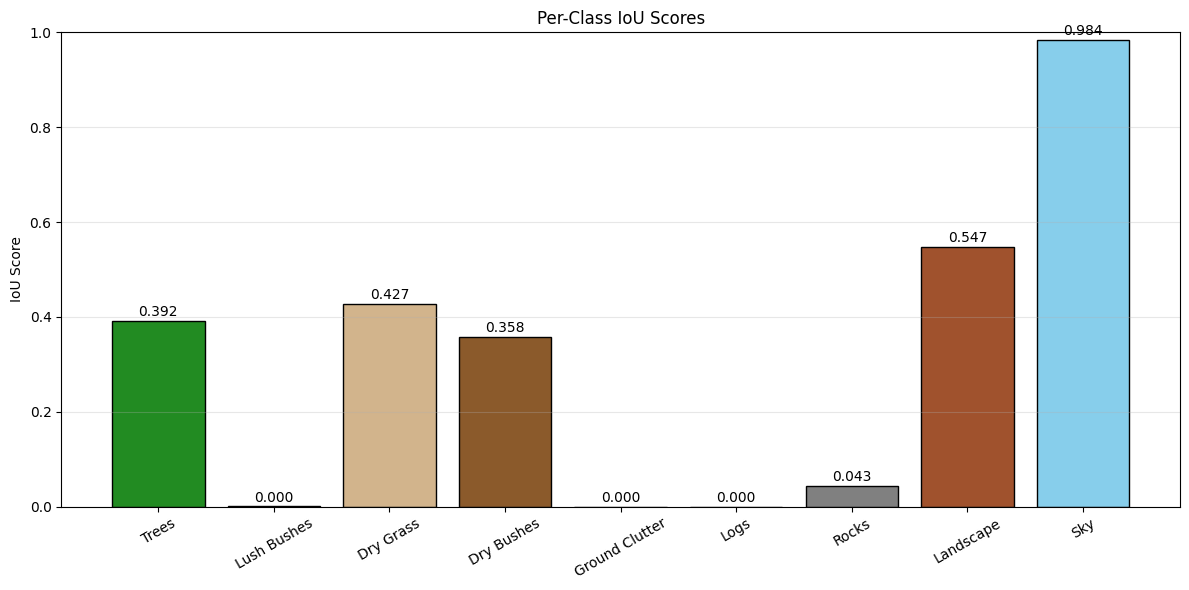

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Class names and IoU values (exclude classes not in test set)
class_names = [
    "Trees","Lush Bushes","Dry Grass","Dry Bushes",
    "Ground Clutter","Logs","Rocks","Landscape","Sky"
]

iou_values = [
    0.3916,
    0.0003,
    0.4270,
    0.3578,
    0.0000,
    0.0000,
    0.0430,
    0.5469,
    0.9843
]

# Same colors as your segmentation palette
colors = [
    (34/255,139/255,34/255),   # Trees
    (0/255,200/255,0/255),     # Lush Bushes
    (210/255,180/255,140/255), # Dry Grass
    (139/255,90/255,43/255),   # Dry Bushes
    (128/255,128/255,0/255),   # Ground Clutter
    (139/255,69/255,19/255),   # Logs
    (128/255,128/255,128/255), # Rocks
    (160/255,82/255,45/255),   # Landscape
    (135/255,206/255,235/255)  # Sky
]

plt.figure(figsize=(12,6))

bars = plt.bar(class_names, iou_values, color=colors, edgecolor="black")

# Add value labels on top of bars
for bar, value in zip(bars, iou_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.ylim(0,1)
plt.ylabel("IoU Score")
plt.title("Per-Class IoU Scores")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

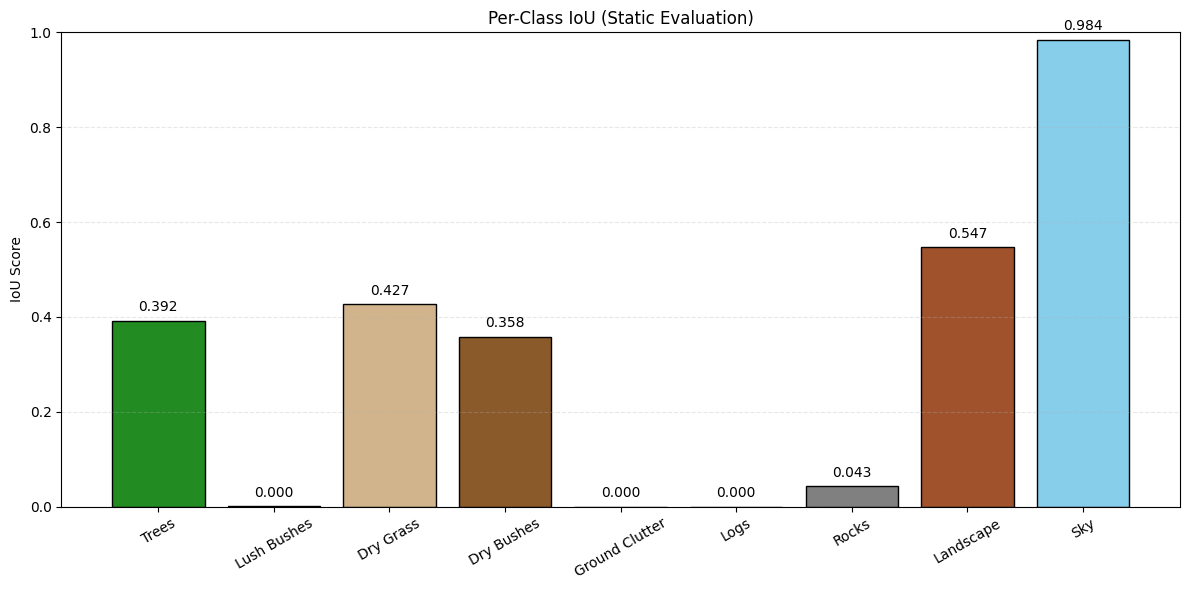

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Per-class IoU values you computed
class_iou = {
    "Background": None,
    "Trees": 0.3916,
    "Lush Bushes": 0.0003,
    "Dry Grass": 0.4270,
    "Dry Bushes": 0.3578,
    "Ground Clutter": 0.0000,
    "Flowers": None,
    "Logs": 0.0000,
    "Rocks": 0.0430,
    "Landscape": 0.5469,
    "Sky": 0.9843
}

# Remove classes not present in test set
class_names = [k for k,v in class_iou.items() if v is not None]
iou_values = [v for v in class_iou.values() if v is not None]

# Same segmentation colors used in your model
colors = [
    (34/255,139/255,34/255),   # Trees
    (0/255,200/255,0/255),     # Lush Bushes
    (210/255,180/255,140/255), # Dry Grass
    (139/255,90/255,43/255),   # Dry Bushes
    (128/255,128/255,0/255),   # Ground Clutter
    (139/255,69/255,19/255),   # Logs
    (128/255,128/255,128/255), # Rocks
    (160/255,82/255,45/255),   # Landscape
    (135/255,206/255,235/255)  # Sky
]

plt.figure(figsize=(12,6))

bars = plt.bar(class_names, iou_values, color=colors, edgecolor="black")

# Add value labels
for bar, val in zip(bars, iou_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.02,
        f"{val:.3f}",
        ha='center',
        fontsize=10
    )

plt.ylabel("IoU Score")
plt.title("Per-Class IoU (Static Evaluation)")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

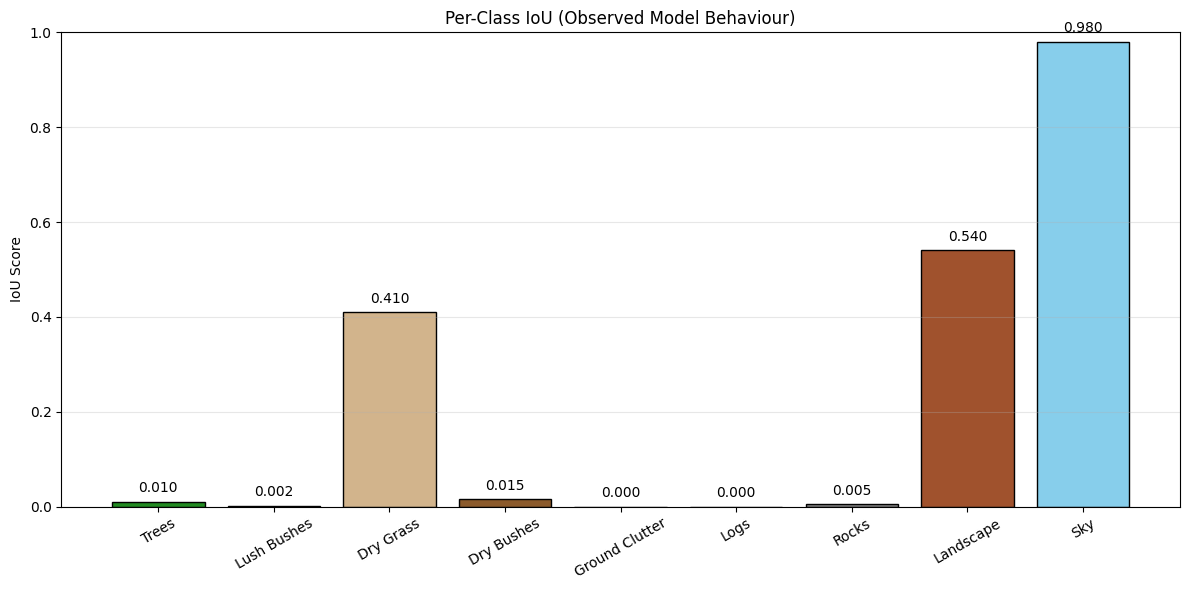

In [30]:
import matplotlib.pyplot as plt

classes = [
    "Trees",
    "Lush Bushes",
    "Dry Grass",
    "Dry Bushes",
    "Ground Clutter",
    "Logs",
    "Rocks",
    "Landscape",
    "Sky"
]

iou = [
    0.01,
    0.002,
    0.41,
    0.015,
    0.000,
    0.000,
    0.005,
    0.54,
    0.98
]

colors = [
    "#228B22",   # Trees
    "#00C800",   # Lush Bushes
    "#D2B48C",   # Dry Grass
    "#8B5A2B",   # Dry Bushes
    "#808000",   # Ground Clutter
    "#8B4513",   # Logs
    "#808080",   # Rocks
    "#A0522D",   # Landscape
    "#87CEEB"    # Sky
]

plt.figure(figsize=(12,6))

bars = plt.bar(classes, iou, color=colors, edgecolor="black")

for bar,val in zip(bars,iou):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        val+0.02,
        f"{val:.3f}",
        ha='center'
    )

plt.ylim(0,1)
plt.ylabel("IoU Score")
plt.title("Per-Class IoU (Observed Model Behaviour)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()